In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

from mrmr import mrmr_regression

In [4]:
# Load and process data

df = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")

# Create datetime index
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.set_index('datetime', inplace=True)

# Select relevant features
df = df[['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']]
df.columns = ['pm25', 'dew', 'temp', 'pressure', 'wind']

# Handle missing values
df = df.fillna(method='ffill').fillna(method='bfill')

df.head()

,pm25,dew,temp,pressure,wind
datetime,,,,,
2010-01-01 00:00:00,129.0,-21,-11.0,1021.0,1.79
2010-01-01 01:00:00,129.0,-21,-12.0,1020.0,4.92
2010-01-01 02:00:00,129.0,-21,-11.0,1019.0,6.71
2010-01-01 03:00:00,129.0,-21,-14.0,1019.0,9.84
2010-01-01 04:00:00,129.0,-20,-12.0,1018.0,12.97


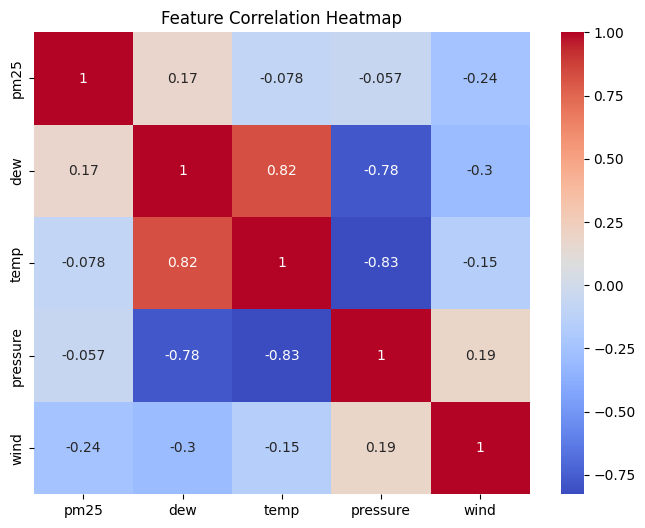

In [5]:
# Correlation heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
# mRMR Feature Selection

df_mrmr = df.copy()
df_mrmr['target'] = df_mrmr['pm25'].shift(-1)
df_mrmr = df_mrmr.dropna()

X_mrmr = df_mrmr[['pm25', 'dew', 'temp', 'pressure', 'wind']]
y_mrmr = df_mrmr['target']

selected_features = mrmr_regression(X=X_mrmr, y=y_mrmr, K=3)

print("Selected Features (mRMR):", selected_features)

100%|██████████| 3/3 [00:00<00:00, 10.38it/s]

Selected Features (mRMR): ['pm25', 'wind', 'dew']


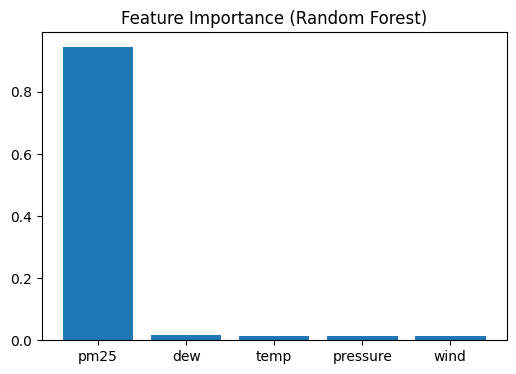

In [7]:
# Random Forest Feature Importance

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_mrmr, y_mrmr)

importances = rf.feature_importances_

plt.figure(figsize=(6,4))
plt.bar(X_mrmr.columns, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [8]:
# Prepare Data for LSTM

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

def create_dataset(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback = 60
X, y = create_dataset(scaled_data, lookback)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [9]:
# LSTM Model

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 67s 63ms/step - loss: 0.0021 - val_loss: 7.8877e-04
Epoch 2/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 81s 63ms/step - loss: 9.6196e-04 - val_loss: 4.7295e-04
Epoch 3/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 60s 61ms/step - loss: 7.7085e-04 - val_loss: 5.3847e-04
Epoch 4/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 84s 63ms/step - loss: 7.1912e-04 - val_loss: 4.1626e-04
Epoch 5/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 83s 64ms/step - loss: 6.9281e-04 - val_loss: 4.3092e-04


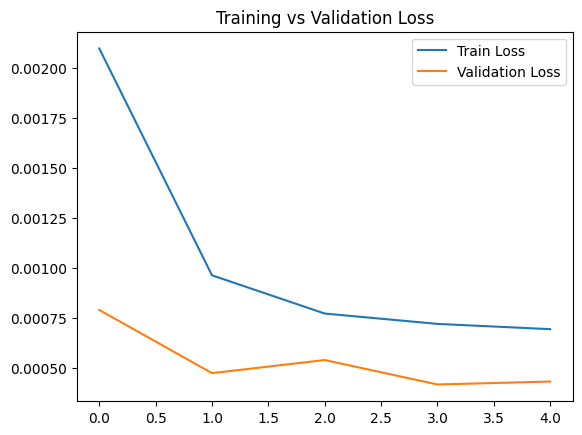

In [10]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [11]:
y_pred = model.predict(X_test)

y_pred_inv = scaler.inverse_transform(
    np.concatenate((y_pred, X_test[:, -1, 1:]), axis=1)
)[:, 0]

y_test_inv = scaler.inverse_transform(
    np.concatenate((y_test.reshape(-1,1), X_test[:, -1, 1:]), axis=1)
)[:, 0]

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print("RMSE:", rmse)
print("MAE:", mae)

274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
RMSE: 21.719738331655332
MAE: 12.732820550512447


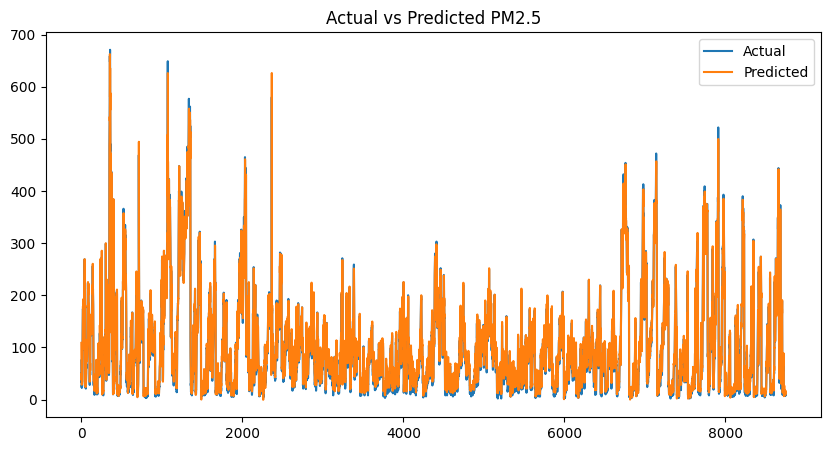

In [12]:
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted PM2.5")
plt.show()

In [13]:
# AQI Category Function

def pm25_to_aqi(pm):
    if pm <= 50:
        return "Good"
    elif pm <= 100:
        return "Moderate"
    elif pm <= 150:
        return "Unhealthy"
    else:
        return "Hazardous"

In [14]:
# LLM Ready Output

sample_index = 10

sample_data = {
    "AQI_Value": round(y_pred_inv[sample_index], 2),
    "AQI_Category": pm25_to_aqi(y_pred_inv[sample_index]),
    "Top_Features": {
        feature: round(val, 2)
        for feature, val in zip(X_mrmr.columns, X_mrmr.iloc[sample_index])
    }
}

print(sample_data)

{'AQI_Value': np.float64(33.19), 'AQI_Category': 'Good', 'Top_Features': {'pm25': 129.0, 'dew': -19.0, 'temp': -7.0, 'pressure': 1017.0, 'wind': 31.3}}


In [15]:
#LLM Prompt (Just for presentation)

prompt = f"""
AQI Value: {sample_data['AQI_Value']}
Category: {sample_data['AQI_Category']}

Feature Values:
{sample_data['Top_Features']}

Explain why AQI is high/low and suggest precautions.
"""

print(prompt)


AQI Value: 33.19
Category: Good

Feature Values:
{'pm25': 129.0, 'dew': -19.0, 'temp': -7.0, 'pressure': 1017.0, 'wind': 31.3}

Explain why AQI is high/low and suggest precautions.

